# 8. Resultado da calibracao -- Soja no Parana

Consolida os arquivos gerados pela etapa 7 (Optimization) para responder duas perguntas:

1. **Qual o resultado medio da otimizacao?** (RMSE agregado por municipio, no geral e por cluster)
2. **Como a produtividade simulada se compara a observada?** (comparacao ano a ano, por municipio)

Importante: a comparacao e feita contra `dyield` (a produtividade **destendenciada**, etapa 5),
que e o alvo que a etapa 7 efetivamente tentou reproduzir -- e nao a produtividade bruta do
IBGE. Isso e proposital: o WOFOST simula o efeito do clima ano a ano, nao o efeito de
tecnologia/manejo que muda a produtividade "de base" ao longo do tempo; comparar contra o
`dyield` isola exatamente a parte que o modelo pode captar. `dyield` fica na mesma escala
(kg/ha) da produtividade real, ancorado no ultimo ano da serie (2024), entao os valores
continuam intuitivos.


In [1]:
import glob
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.join(os.getcwd(), 'util'))
from util.utils_soja_pr import setup_paths_soja_pr

paths = setup_paths_soja_pr()
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


## 1. Resultado medio da otimizacao (RMSE agregado por municipio)


In [2]:
summary_path = os.path.join(paths['OPTIMIZATION'], 'optimization_summary_pr.json')

with open(summary_path) as f:
    summary = json.load(f)

df_summary = pd.DataFrame(summary)
print(f"Municipios calibrados: {len(df_summary)}")
print(f"\nRMSE agregado (por municipio, media de todos os anos-safra):")
print(f"  Media:   {df_summary['rmse_aggregated'].mean():.2f} kg/ha")
print(f"  Mediana: {df_summary['rmse_aggregated'].median():.2f} kg/ha")
print(f"  Desvio:  {df_summary['rmse_aggregated'].std():.2f} kg/ha")
print(f"  Min/Max: {df_summary['rmse_aggregated'].min():.2f} / {df_summary['rmse_aggregated'].max():.2f} kg/ha")

print("\nRMSE medio por cluster:")
resumo_cluster = df_summary.groupby('cluster_id').agg(
    n_municipios=('point_id', 'count'),
    rmse_medio=('rmse_aggregated', 'mean'),
    rmse_mediano=('rmse_aggregated', 'median'),
).round(2)
print(resumo_cluster)


Municipios calibrados: 392

RMSE agregado (por municipio, media de todos os anos-safra):
  Media:   1887756685.50 kg/ha
  Mediana: 1391.26 kg/ha
  Desvio:  3918302153.64 kg/ha
  Min/Max: 192.43 / 10000000000.00 kg/ha

RMSE medio por cluster:
            n_municipios    rmse_medio  rmse_mediano
cluster_id                                          
0.0                  191  1.570702e+08  1.175650e+03
1.0                   57  1.754387e+09  1.446950e+03
2.0                   71  8.591549e+09  1.000000e+10
3.0                   73  1.738920e+03  1.082070e+03


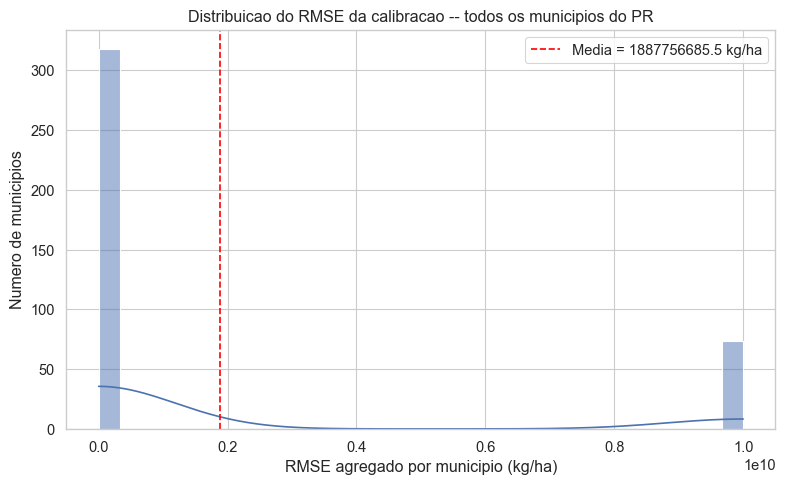

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(df_summary['rmse_aggregated'], bins=30, kde=True)
plt.axvline(df_summary['rmse_aggregated'].mean(), color='red', linestyle='--',
            label=f"Media = {df_summary['rmse_aggregated'].mean():.1f} kg/ha")
plt.xlabel('RMSE agregado por municipio (kg/ha)')
plt.ylabel('Numero de municipios')
plt.title('Distribuicao do RMSE da calibracao -- todos os municipios do PR')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Produtividade simulada vs observada (destendenciada), ano a ano


In [4]:
metrics_files = glob.glob(os.path.join(paths['OPTIMIZATION'], "OPT_MULTIYEAR_cluster*_point*_yearly_metrics.csv"))
print(f"Arquivos de metricas anuais encontrados: {len(metrics_files)}")

df_metrics = pd.concat([pd.read_csv(f) for f in metrics_files], ignore_index=True)
df_metrics['point_id'] = df_metrics['point_id'].astype(str)

# Anexa o nome do municipio, se as coordenadas estiverem disponiveis
if os.path.exists(paths['COORDINATES']):
    df_locs = pd.read_excel(paths['COORDINATES'], sheet_name='SIDRA-ids')
    df_locs['cod_municipio'] = df_locs['cod_municipio'].astype(str)
    df_metrics = df_metrics.merge(
        df_locs[['cod_municipio', 'name']].rename(columns={'cod_municipio': 'point_id', 'name': 'municipio'}),
        on='point_id', how='left'
    )

df_metrics = df_metrics.dropna(subset=['dyield_obs', 'dyield_sim'])
print(f"Pares observado/simulado validos: {len(df_metrics)} (municipio-ano)")
df_metrics.head()


Arquivos de metricas anuais encontrados: 392
Pares observado/simulado validos: 3166 (municipio-ano)


,point_id,cluster_id,year,dyield_obs,dyield_sim,error,abs_error,r2,bias,municipio
0,4100103,0.0,2015,2760.000000,7727.696715,4967.696715,4967.696715,-242.08926,1791.872011,Abatiá
1,4100103,0.0,2016,3121.967213,7355.920149,4233.952936,4233.952936,-242.08926,1791.872011,Abatiá
2,4100103,0.0,2017,3056.547945,5880.666062,2824.118117,2824.118117,-242.08926,1791.872011,Abatiá
3,4100103,0.0,2018,3063.452055,1164.759548,-1898.692507,1898.692507,-242.08926,1791.872011,Abatiá
4,4100103,0.0,2019,3480.000000,1157.803266,-2322.196734,2322.196734,-242.08926,1791.872011,Abatiá


In [5]:
obs = df_metrics['dyield_obs'].values
sim = df_metrics['dyield_sim'].values

rmse_geral = np.sqrt(np.mean((sim - obs) ** 2))
mae_geral = np.mean(np.abs(sim - obs))
bias_geral = np.mean(sim - obs)
r2_geral = np.corrcoef(obs, sim)[0, 1] ** 2

print("Metricas globais (todos os municipios, todas as safras):")
print(f"  RMSE: {rmse_geral:.2f} kg/ha")
print(f"  MAE:  {mae_geral:.2f} kg/ha")
print(f"  Bias: {bias_geral:+.2f} kg/ha (positivo = modelo superestima)")
print(f"  R²:   {r2_geral:.3f}")


Metricas globais (todos os municipios, todas as safras):
  RMSE: 19064.49 kg/ha
  MAE:  3025.68 kg/ha
  Bias: +1622.26 kg/ha (positivo = modelo superestima)
  R²:   0.002


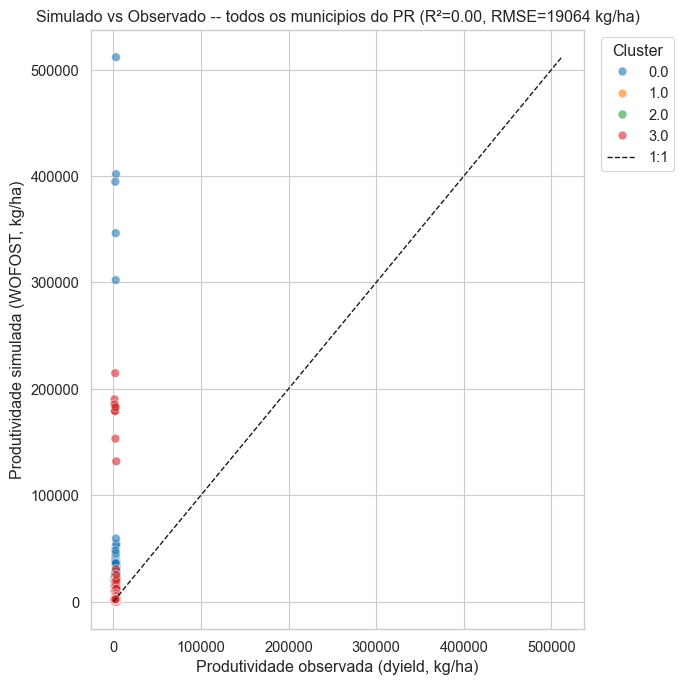

In [6]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_metrics, x='dyield_obs', y='dyield_sim', hue='cluster_id',
                 palette='tab10', alpha=0.6, s=40)

lim_min = min(df_metrics['dyield_obs'].min(), df_metrics['dyield_sim'].min())
lim_max = max(df_metrics['dyield_obs'].max(), df_metrics['dyield_sim'].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='1:1')

plt.xlabel('Produtividade observada (dyield, kg/ha)')
plt.ylabel('Produtividade simulada (WOFOST, kg/ha)')
plt.title(f'Simulado vs Observado -- todos os municipios do PR (R²={r2_geral:.2f}, RMSE={rmse_geral:.0f} kg/ha)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 3. Melhores e piores ajustes por municipio


In [7]:
resumo_municipio = df_metrics.groupby(['point_id', 'municipio', 'cluster_id']).apply(
    lambda g: pd.Series({
        'n_anos': len(g),
        'rmse': np.sqrt(np.mean((g['dyield_sim'] - g['dyield_obs']) ** 2)),
        'bias': (g['dyield_sim'] - g['dyield_obs']).mean(),
        'obs_medio': g['dyield_obs'].mean(),
        'sim_medio': g['dyield_sim'].mean(),
    }),
    include_groups=False
).reset_index().sort_values('rmse')

print("10 melhores ajustes (menor RMSE):")
print(resumo_municipio.head(10).round(1).to_string(index=False))

print("\n10 piores ajustes (maior RMSE):")
print(resumo_municipio.tail(10).round(1).to_string(index=False))


10 melhores ajustes (menor RMSE):
point_id    municipio  cluster_id  n_anos  rmse   bias  obs_medio  sim_medio
 4120705     Quatiguá         0.0     8.0 192.4   84.8     3964.2     4049.0
 4100608  Alto Paraná         0.0    10.0 258.0  -26.9     2416.9     2390.0
 4126405    Sertaneja         0.0    10.0 332.5 -221.3     2539.1     2317.8
 4100202 Adrianópolis         2.0     3.0 335.6  169.6     3444.3     3613.9
 4120002     Porecatu         0.0    10.0 355.6  -21.4     2413.1     2391.8
 4108106      Flórida         0.0    10.0 383.0 -211.9     3014.8     2802.9
 4105409  Chopinzinho         1.0    10.0 388.3  -75.0     2969.3     2894.3
 4102406 Bandeirantes         0.0    10.0 398.4   87.6     2970.7     3058.3
 4112306       Japira         0.0    10.0 406.8 -103.4     3380.6     3277.2
 4128807       Xambrê         3.0    10.0 412.9 -170.4     1973.9     1803.4

10 piores ajustes (maior RMSE):
point_id                   municipio  cluster_id  n_anos     rmse     bias  obs_medio 

In [8]:
resultado_path = os.path.join(paths['OPTIMIZATION'], 'resultado_comparativo_obs_sim.csv')
df_metrics.to_csv(resultado_path, index=False)

resumo_path = os.path.join(paths['OPTIMIZATION'], 'resumo_por_municipio.csv')
resumo_municipio.to_csv(resumo_path, index=False)

print(f"Comparativo ano a ano salvo em: {resultado_path}")
print(f"Resumo por municipio salvo em: {resumo_path}")


Comparativo ano a ano salvo em: d:\_py\AgroIA_prod\output\soja_pr\Optimization\resultado_comparativo_obs_sim.csv
Resumo por municipio salvo em: d:\_py\AgroIA_prod\output\soja_pr\Optimization\resumo_por_municipio.csv
